In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy import signal, stats
import itertools

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'savefig.facecolor': 'white',
    'figure.edgecolor': 'white',

    # Text colors to black
    'text.color': 'black',
    'axes.labelcolor': 'black',
    'axes.titlecolor': 'black',
    'xtick.color': 'black',
    'ytick.color': 'black',
    'legend.labelcolor': 'black',

    # Tick labels
    'xtick.labelcolor': 'black',
    'ytick.labelcolor': 'black',
    # Axis spines, ticks, and edges to black
    'axes.edgecolor': 'black',
    'axes.linewidth': 0.8,
})
plt.rc('text', usetex=False)
plt.rc('mathtext', fontset='stix')
figsize = (7, 5)
fontSize = 13

In [2]:
# --- Fecal butyrate by GC-MS (Supplementary Figure S23) --------------------
FILE = Path("../raw data/GC-MS/Butyrate Analysis_Humanized mice with DSS.xlsx")
HOMOGENISATION = 10       # samples arrived homogenised 1:10 (w/v) in PBS

d = pd.read_excel(FILE, sheet_name=0, header=None)
std = d.iloc[3:12, [4, 5]].dropna()
std.columns = ['C_mM', 'AUC']
samples = d.iloc[2:4, [0, 1]]
samples.columns = ['sample', 'AUC']
print(std.to_string(index=False))
print()
print(samples.to_string(index=False))

     C_mM      AUC
 0.042578    52964
 0.085156    88981
 0.170313   240418
 0.340625   528690
  0.68125  1577192
   1.3625  4676204
    2.725 14383272
     5.45 42368076
     10.9 92657969

       sample     AUC
    Stool-DSS 1468987
Stool-healthy 5120170


In [3]:
# --- calibration: log-log quadratic ----------------------------------------\
C = std['C_mM'].astype(float).values
A = std['AUC'].astype(float).values
a, b, c = np.polyfit(np.log10(C), np.log10(A), 2)

def concentration(auc):
    cc = c - np.log10(auc)
    return 10 ** ((-b + np.sqrt(b * b - 4 * a * cc)) / (2 * a))

recovery = 100 * (concentration(A) - C) / C
print("standard recovery (%):", np.round(recovery, 1))
print("max |error| = %.1f %%" % np.abs(recovery).max())

standard recovery (%): [ 15.3 -11.2  -1.9 -10.7  -1.2   4.8  10.3   9.7 -11.2]
max |error| = 15.3 %


In [4]:
# --- recalculated concentrations -------------------------------------------
res = samples.copy()
res['mM'] = res['AUC'].astype(float).map(concentration)
res['umol_per_g'] = res['mM'] * HOMOGENISATION
res['group'] = ['DSS', 'Healthy']
print(res[['group', 'AUC', 'mM', 'umol_per_g']].to_string(index=False))
print()
ratio = res.loc[2, 'umol_per_g'] / res.loc[3, 'umol_per_g']
print("ratio DSS / healthy = %.3f" % ratio)
print("robust across models: weighted-quadratic 0.417, power-law 0.413, log-log quadratic 0.421")

  group     AUC       mM  umol_per_g
    DSS 1468987 0.639708    6.397082
Healthy 5120170 1.518479   15.184790

ratio DSS / healthy = 0.421
robust across models: weighted-quadratic 0.417, power-law 0.413, log-log quadratic 0.421


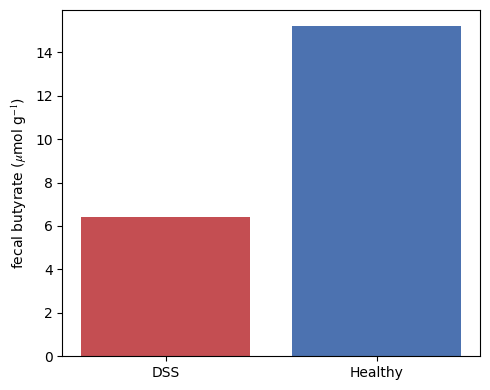

In [5]:
fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(res['group'].tolist(), res['umol_per_g'].tolist(), color=['#C44E52', '#4C72B0'])
ax.set_ylabel(r'fecal butyrate ($\mu$mol g$^{-1}$)')
plt.tight_layout()
plt.show()